In [25]:
# ==========================================
# IMPORTS
# ==========================================
!pip install emoji

import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "../data/raw/dev.tsv",
    sep="\t"
)

df.head()

   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   -------------------------------- ----- 524.3/608.4 kB 840.2 kB/s eta 0:00:01
   ---------------------------------------- 608.4/608.4 kB 792.4 kB/s  0:00:01



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,tweet,label
0,Leo nimepata kitambulisho changu cha taifa Asa...,positive
1,Asante na tafadhali subiri tutawasiliana nawe ...,positive
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,neutral
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,neutral
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,negative


## Data Information

In [26]:
print(df.info())

print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   453 non-null    object
 1   label   453 non-null    object
dtypes: object(2)
memory usage: 7.2+ KB
None
label
neutral     268
positive    137
negative     48
Name: count, dtype: int64


## VISUALIZE DATA DISTRIBUTION

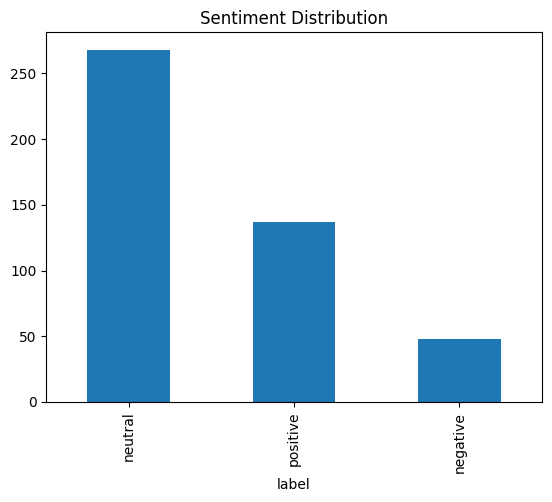

In [27]:
# ==========================================
# VISUALIZE LABEL DISTRIBUTION
# ==========================================

df['label'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")

plt.show()

## DATA CLEANING

In [28]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#\w+', '', text)

    text = emoji.replace_emoji(text, replace='')

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [29]:
# ==========================================
# APPLY CLEANING
# ==========================================

df['clean_text'] = df['tweet'].apply(clean_text)

df.head()

,tweet,label,clean_text
0,Leo nimepata kitambulisho changu cha taifa Asa...,positive,leo nimepata kitambulisho changu cha taifa asa...
1,Asante na tafadhali subiri tutawasiliana nawe ...,positive,asante na tafadhali subiri tutawasiliana nawe ...
2,Takwimu zinaonyesha katika kila watoto 100 27 ...,neutral,takwimu zinaonyesha katika kila watoto wanapat...
3,Kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...,neutral,kwa hiyo kama ilivyokuja kwenye aya hiyo ni ju...
4,Sio watu wazuri awa Nakutana nao FA Cup nawafa...,negative,sio watu wazuri awa nakutana nao fa cup nawafa...


## LABEL ENCODING

In [30]:
label_map = {
    'negative':0,
    'neutral':1,
    'positive':2
}

df['label_encoded'] = df['label'].map(label_map)

## SPLIT DATA

In [31]:
X_train, X_test, y_train, y_test = train_test_split(

    df['clean_text'],

    df['label_encoded'],

    test_size=0.2,

    random_state=42,

    stratify=df['label_encoded']
)

print(X_train.shape)
print(X_test.shape)

(362,)
(91,)


## SAVE CLEANED DATA

In [32]:
# ==========================================
# SAVE CLEANED DATA
# ==========================================

df.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

print("Cleaned data saved.")

Cleaned data saved.
